In [1]:
%matplotlib inline
## Standalone setup: full joint library + precomputed deepSHAP attrs + (lfc, cossim) axes.
import os, sys, json, numpy as np, pandas as pd, matplotlib.pyplot as plt

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import EigenMap, ENHANCER_LEN
ENH = ENHANCER_LEN

CT = {'K562': 'K562_twostep_v6_do075', 'HepG2': 'HepG2_twostep_v6_do03'}

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device='cpu')
em.load_from_dataframe(df, seq_col='sequence')

raw = np.load(os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n_full = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n_full][keep]
    em.attr_hyp[ct] = hyp
    em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][:n_full][keep]

cossim = em.cosine_similarity(mode='importance', zscore=True)
lfc    = df['HepG2_log2FC'].values - df['K562_log2FC'].values
fin    = np.isfinite(cossim) & np.isfinite(lfc)

print(f'{len(df)} seqs   X={tuple(em.X.shape)}   fin={fin.sum()}')

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_twostep_v6_do075', 'HepG2': 'HepG2_twostep_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
56975 seqs   X=(56975, 4, 281)   fin=56975


In [2]:
## Load modisco patterns (for CWMs), finemo hits, and TOMTOM-JASPAR matches.
## Auto-pick CTCF patterns per ct by string-matching "CTCF" in the tomtom annotation.
import h5py
from types import SimpleNamespace

MODISCO_DIR = os.path.join(REPO, 'genomic_targets/data/modisco')
HP_TAG      = f'full56k_enh{ENH}_default'
TOMTOM_JSON = os.path.join(MODISCO_DIR, f'tomtom_jaspar2026_{HP_TAG}.json')

def load_patterns(h5_path, group):
    with h5py.File(h5_path, 'r') as f:
        if group not in f: return []
        names = sorted(f[group].keys(), key=lambda s: int(s.split('_')[-1]))
        return [SimpleNamespace(contrib_scores=f[group][nm]['contrib_scores'][...]) for nm in names]

results_full = {ct: (load_patterns(os.path.join(MODISCO_DIR, f'{ct}_{HP_TAG}.h5'), 'pos_patterns'),
                     load_patterns(os.path.join(MODISCO_DIR, f'{ct}_{HP_TAG}.h5'), 'neg_patterns'))
                for ct in CT}

hits = {ct: pd.read_csv(os.path.join(REPO, f'genomic_targets/data/motif/{ct}/hits.tsv'),
                        sep='\t', usecols=['motif_name','peak_id','start','end','strand'])
        for ct in CT}

# tomtom keys: "{ct}/pos_patterns.pattern_{i}" -> "MA#### TFNAME"; same name format as hits.tsv
tomtom = json.load(open(TOMTOM_JSON))
CTCF_PATTERNS = {ct: [] for ct in CT}
ctcf_match = {}
for key, ann in tomtom.items():
    if 'CTCF' not in ann.upper(): continue
    ct, name = key.split('/', 1)
    CTCF_PATTERNS[ct].append(name)
    ctcf_match[(ct, name)] = ann

for ct, ms in CTCF_PATTERNS.items():
    print(f'{ct}: {len(ms)} CTCF patterns -> {ms}')

ctcf_idx = {ct: np.array(sorted(hits[ct].loc[hits[ct]['motif_name'].isin(CTCF_PATTERNS[ct]),
                                             'peak_id'].unique()), dtype=int)
            for ct in CT}
print('CTCF-hit seqs per ct:', {ct: len(v) for ct, v in ctcf_idx.items()})

K562: 3 CTCF patterns -> ['neg_patterns.pattern_7', 'pos_patterns.pattern_14', 'pos_patterns.pattern_2']
HepG2: 2 CTCF patterns -> ['neg_patterns.pattern_1', 'pos_patterns.pattern_25']
CTCF-hit seqs per ct: {'K562': 11832, 'HepG2': 9971}


AlphaGenome patches applied (all functional activations -> nn.Module).
K562  neg_patterns.pattern_7  MA1930.2 CTCF   hits=47
K562  pos_patterns.pattern_14  MA0139.2 CTCF   hits=3555
K562  pos_patterns.pattern_2  MA0139.2 CTCF   hits=9681
HepG2  neg_patterns.pattern_1  MA0139.2 CTCF   hits=4046
HepG2  pos_patterns.pattern_25  MA0139.2 CTCF   hits=6128


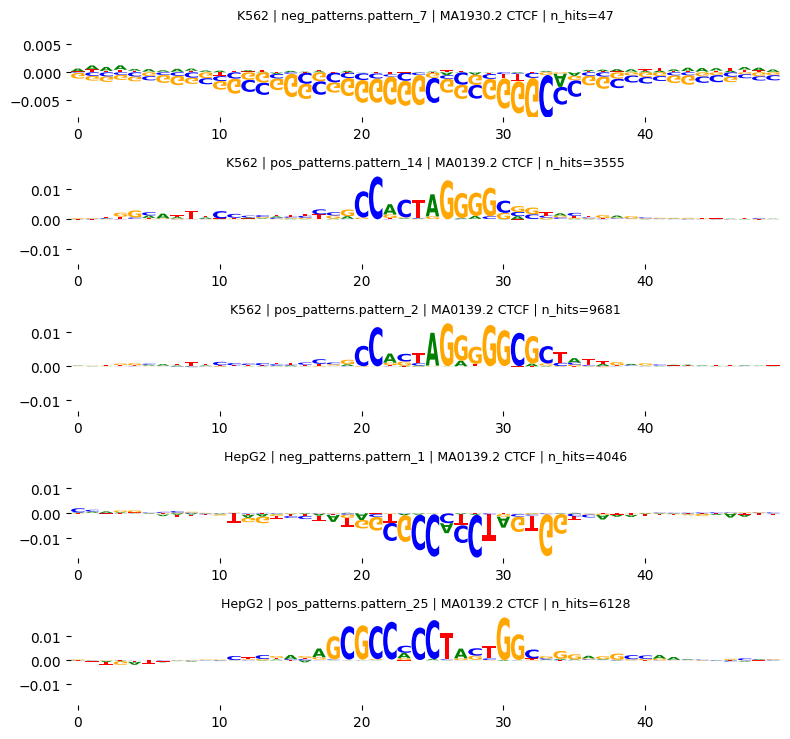

In [3]:
## Print CTCF-matched patterns + show their CWMs (one row per ct).
import eigen_steering as es
es._load_heavy_deps()
fast_logo = es.fast_logo

def get_cwm(ct, motif_name):
    grp, idx = motif_name.split('.')
    i = int(idx.split('_')[-1])
    return (results_full[ct][0] if grp == 'pos_patterns' else results_full[ct][1])[i].contrib_scores

n_rows = sum(len(ms) for ms in CTCF_PATTERNS.values())
fig, axes = plt.subplots(n_rows, 1, figsize=(8, 1.5 * n_rows), squeeze=False)
r = 0
for ct in CT:
    for m in CTCF_PATTERNS[ct]:
        cwm = get_cwm(ct, m)
        n_hits = (hits[ct]['motif_name'] == m).sum()
        ann = ctcf_match[(ct, m)]
        print(f'{ct}  {m:20s}  {ann}   hits={n_hits}')
        ax = axes[r, 0]
        yabs = max(abs(cwm).max() * 1.05, 1e-6)
        fast_logo(cwm.T, ax=ax, ylim=(-yabs, yabs))
        ax.set_title(f'{ct} | {m} | {ann} | n_hits={n_hits}', fontsize=9)
        for sp in ax.spines.values(): sp.set_visible(False)
        r += 1
plt.tight_layout(); plt.show()

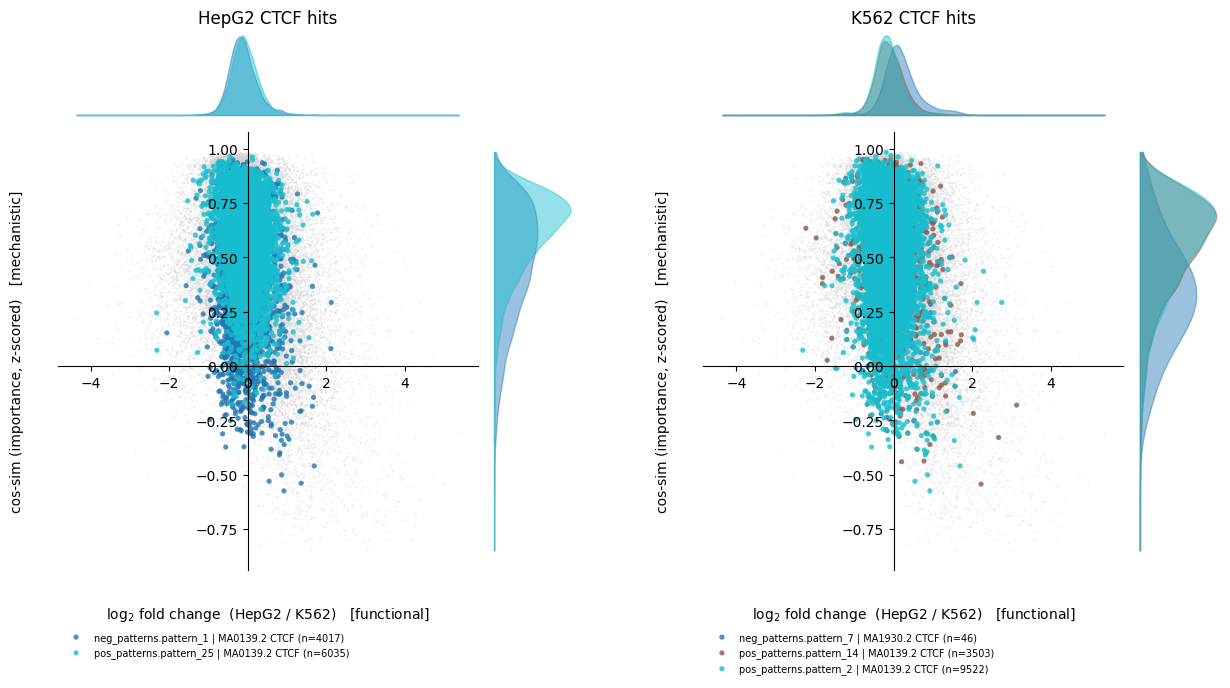

In [4]:
## Two panels (HepG2 / K562) with KDE marginals. Color = CTCF pattern.
## A seq hit by multiple CTCF patterns shows up once per pattern.
from scipy.stats import gaussian_kde

fig = plt.figure(figsize=(15, 7))
outer = fig.add_gridspec(1, 2, wspace=0.25)
xs = np.linspace(np.nanmin(lfc[fin]),    np.nanmax(lfc[fin]),    400)
ys = np.linspace(np.nanmin(cossim[fin]), np.nanmax(cossim[fin]), 400)

for col, ct in enumerate(['HepG2', 'K562']):
    pats   = CTCF_PATTERNS[ct]
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(pats), 1)))

    gs = outer[col].subgridspec(2, 2, width_ratios=(5, 1), height_ratios=(1, 5),
                                wspace=0.05, hspace=0.05)
    ax     = fig.add_subplot(gs[1, 0])
    ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_rgt = fig.add_subplot(gs[1, 1], sharey=ax)

    ax.scatter(lfc[fin], cossim[fin], s=2, c='lightgray', alpha=0.4,
               edgecolors='none', rasterized=True)

    for color, m in zip(colors, pats):
        idx = hits[ct].loc[hits[ct]['motif_name'] == m, 'peak_id'].unique().astype(int)
        ann = ctcf_match[(ct, m)]
        ax.scatter(lfc[idx], cossim[idx], s=14, c=[color], alpha=0.8,
                   edgecolors='none', label=f'{m} | {ann} (n={len(idx)})')
        if len(idx) > 1:
            ax_top.fill_between(xs, gaussian_kde(lfc[idx])(xs),    color=color, alpha=0.45)
            ax_rgt.fill_betweenx(ys, gaussian_kde(cossim[idx])(ys), color=color, alpha=0.45)

    ax.spines['left'].set_position('zero'); ax.spines['bottom'].set_position('zero')
    ax.spines['top'].set_visible(False);    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom');  ax.yaxis.set_ticks_position('left')
    ax.set_xlabel('log$_2$ fold change  (HepG2 / K562)   [functional]')
    ax.set_ylabel('cos-sim (importance, z-scored)   [mechanistic]')
    ax.xaxis.set_label_coords(0.5, -0.08)
    ax.yaxis.set_label_coords(-0.08, 0.5)
    ax.legend(frameon=False, fontsize=7, loc='upper left', bbox_to_anchor=(0, -0.12))
    ax_top.set_title(f'{ct} CTCF hits')
    for a in (ax_top, ax_rgt):
        a.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for sp in a.spines.values(): sp.set_visible(False)

plt.show()

24 HepG2-CTCF-hit SEAM seqs   cossim range: -0.575 .. +0.964
top 5 closest-to-+1 SEAM CTCF seqs (idx, cossim, lfc):
  rank=0  idx=56303  cossim=+0.964  lfc=-0.45
  rank=1  idx=1139  cossim=+0.962  lfc=+0.12
  rank=2  idx=31942  cossim=+0.014  lfc=-0.32
  rank=3  idx=16632  cossim=+0.012  lfc=-0.07
  rank=4  idx=7334  cossim=+0.011  lfc=+0.99
  divergent idx=12355  cossim=-0.575  lfc=+0.92  ctcf=['neg_patterns.pattern_1']
  mid       idx=28389  cossim=+0.000  lfc=-0.65  ctcf=['pos_patterns.pattern_25']
  shared    idx=56303  cossim=+0.964  lfc=-0.45  ctcf=['pos_patterns.pattern_25']


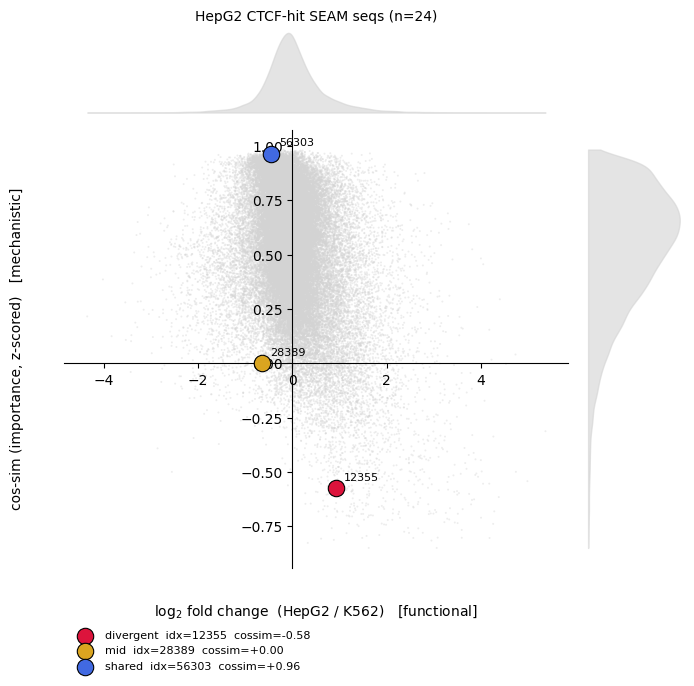

In [5]:
## HepG2 panel: among all HepG2-CTCF-hit SEAM seqs, pick by cossim alone.
##   divergent = closest to -1   |   mid = closest to 0   |   shared = HI_RANK-th closest to +1
## (Patterns differ; cossim is per-seq, not per-pattern.)
HI_RANK = 0   # 0 = closest to +1, 1 = next, etc.

from scipy.stats import gaussian_kde

ct = 'HepG2'
SEAM_DIR = os.path.join(REPO, 'SEAM_target_spaces/results/foregrounds')
seam_set = (set(os.listdir(os.path.join(SEAM_DIR, 'HepG2'))) &
            set(os.listdir(os.path.join(SEAM_DIR, 'K562'))))
seam_idx = np.array(sorted(int(s) for s in seam_set if s.isdigit()))
has_seam = np.zeros(len(df), dtype=bool); has_seam[seam_idx] = True

ctcf_seqs = (hits[ct].loc[hits[ct]['motif_name'].isin(CTCF_PATTERNS[ct]), 'peak_id']
             .unique().astype(int))
cand = ctcf_seqs[fin[ctcf_seqs] & has_seam[ctcf_seqs]]
cs = cossim[cand]
lo_seq  = int(cand[np.abs(cs - (-1)).argmin()])
mid_seq = int(cand[np.abs(cs -   0 ).argmin()])
hi_order = np.argsort(np.abs(cs - 1))
hi_seq   = int(cand[hi_order[HI_RANK]])
print(f'{len(cand)} HepG2-CTCF-hit SEAM seqs   cossim range: {cs.min():+.3f} .. {cs.max():+.3f}')
print(f'top 5 closest-to-+1 SEAM CTCF seqs (idx, cossim, lfc):')
for r in hi_order[:5]:
    si = int(cand[r])
    print(f'  rank={list(hi_order[:5]).index(r)}  idx={si}  cossim={cossim[si]:+.3f}  lfc={lfc[si]:+.2f}')

def patterns_for(ct, seq_i):
    return sorted(hits[ct].loc[(hits[ct]['peak_id'] == seq_i) &
                               (hits[ct]['motif_name'].isin(CTCF_PATTERNS[ct])),
                               'motif_name'].unique())
for tag, seq_i in [('divergent', lo_seq), ('mid', mid_seq), ('shared', hi_seq)]:
    print(f'  {tag:9s} idx={seq_i}  cossim={cossim[seq_i]:+.3f}  '
          f'lfc={lfc[seq_i]:+.2f}  ctcf={patterns_for(ct, seq_i)}')

fig = plt.figure(figsize=(8, 7))
gs = fig.add_gridspec(2, 2, width_ratios=(5, 1), height_ratios=(1, 5),
                      wspace=0.05, hspace=0.05)
ax     = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
ax_rgt = fig.add_subplot(gs[1, 1], sharey=ax)

xs = np.linspace(np.nanmin(lfc[fin]),    np.nanmax(lfc[fin]),    400)
ys = np.linspace(np.nanmin(cossim[fin]), np.nanmax(cossim[fin]), 400)

ax.scatter(lfc[fin], cossim[fin], s=2, c='lightgray', alpha=0.4,
           edgecolors='none', rasterized=True)
ax_top.fill_between(xs, gaussian_kde(lfc[fin])(xs),    color='lightgray', alpha=0.6)
ax_rgt.fill_betweenx(ys, gaussian_kde(cossim[fin])(ys), color='lightgray', alpha=0.6)

picks = [(lo_seq,  'crimson',   'divergent'),
         (mid_seq, 'goldenrod', 'mid'),
         (hi_seq,  'royalblue', 'shared')]
for seq_i, color, tag in picks:
    ax.scatter(lfc[seq_i], cossim[seq_i], s=140, c=color, edgecolors='k', lw=0.8,
               label=f'{tag}  idx={seq_i}  cossim={cossim[seq_i]:+.2f}', zorder=5)
    ax.annotate(str(seq_i), (lfc[seq_i], cossim[seq_i]), fontsize=8,
                xytext=(6, 6), textcoords='offset points')

ax.spines['left'].set_position('zero'); ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_visible(False);    ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('bottom');  ax.yaxis.set_ticks_position('left')
ax.set_xlabel('log$_2$ fold change  (HepG2 / K562)   [functional]')
ax.set_ylabel('cos-sim (importance, z-scored)   [mechanistic]')
ax.xaxis.set_label_coords(0.5, -0.08)
ax.yaxis.set_label_coords(-0.08, 0.5)
ax.legend(frameon=False, fontsize=8, loc='upper left', bbox_to_anchor=(0, -0.12))
ax_top.set_title(f'{ct} CTCF-hit SEAM seqs (n={len(cand)})', fontsize=10)
for a in (ax_top, ax_rgt):
    a.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for sp in a.spines.values(): sp.set_visible(False)
plt.show()

/tmp/slurm_tmp/2078086/ipykernel_3730339/836076172.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


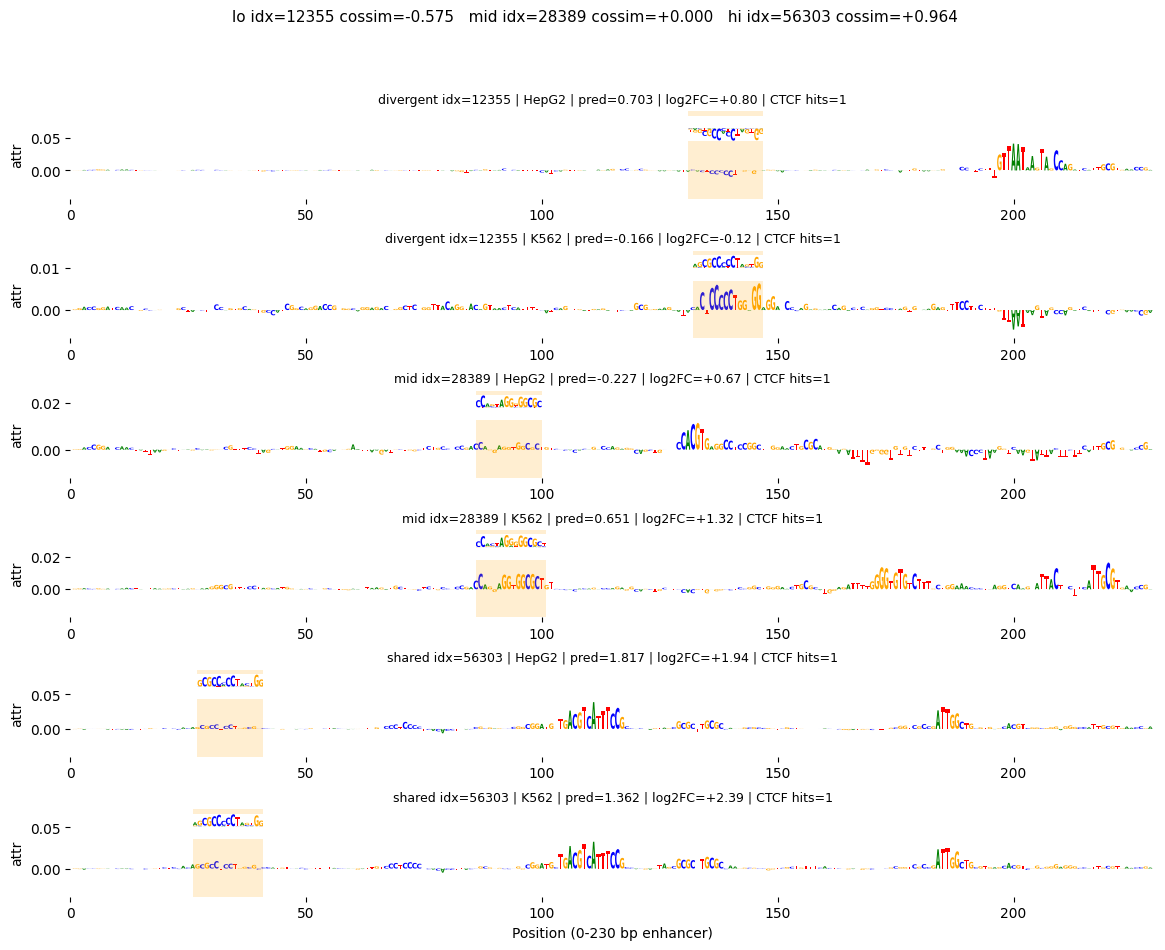

In [6]:
## Attribution logos for the 3 picks (divergent / mid / shared) -- HepG2 and K562 rows.
## Per-ct convention: each row highlights only that ct's own CTCF hit windows.
TRIM_THR = 0.3
CTCF_SET = {ct: set(CTCF_PATTERNS[ct]) for ct in CT}

def trim_cwm(cwm, thr=TRIM_THR):
    imp = np.abs(cwm).sum(axis=1)
    on = imp > thr * imp.max()
    if not on.any(): return cwm
    s, e = on.argmax(), len(on) - on[::-1].argmax()
    return cwm[s:e]

def get_cwm_obj(ct, motif_name):
    grp, idx = motif_name.split('.')
    i = int(idx.split('_')[-1])
    return (results_full[ct][0] if grp == 'pos_patterns' else results_full[ct][1])[i].contrib_scores

ORDER = ['HepG2', 'K562']
PICKS = [(lo_seq, 'divergent'), (mid_seq, 'mid'), (hi_seq, 'shared')]
fig, axes = plt.subplots(len(PICKS) * len(ORDER), 1,
                         figsize=(14, 1.7 * len(PICKS) * len(ORDER)),
                         gridspec_kw={'hspace': 0.6})

for si, (seq_i, tag) in enumerate(PICKS):
    peak_start = int(df['start_hg38'].fillna(0).iloc[seq_i])
    for ci, ct in enumerate(ORDER):
        ax = axes[len(ORDER) * si + ci]
        a = em.attr[ct][seq_i, :, :ENH]
        yabs = abs(a).max() * 1.05
        fast_logo(a, ax=ax, ylim=(-yabs, yabs * 2.1))

        h = hits[ct][(hits[ct]['peak_id'] == seq_i) &
                     (hits[ct]['motif_name'].isin(CTCF_SET[ct]))].copy()
        h['x0'] = h['start'].astype(int) - peak_start
        h['x1'] = h['end'].astype(int)   - peak_start

        for k, hit in h.iterrows():
            ax.axvspan(hit['x0'], hit['x1'], color='orange', alpha=0.18, lw=0)
            cwm = trim_cwm(get_cwm_obj(ct, hit['motif_name']))
            if hit['strand'] == '-': cwm = cwm[::-1, ::-1]
            w = max(hit['x1'] - hit['x0'], 1)
            ins = ax.inset_axes([hit['x0'], yabs * 1.05, w, yabs * 0.9],
                                transform=ax.transData)
            cy = max(abs(cwm).max() * 1.05, 1e-6)
            fast_logo(cwm.T, ax=ins, ylim=(-cy, cy))
            ins.set_xticks([]); ins.set_yticks([])
            for sp in ins.spines.values(): sp.set_visible(False)

        ax.set_title(f'{tag} idx={seq_i} | {ct} | pred={em.predictions[ct][seq_i]:.3f} | '
                     f'log2FC={df[f"{ct}_log2FC"].iloc[seq_i]:+.2f} | '
                     f'CTCF hits={len(h)}', fontsize=9)
        ax.set_ylabel('attr')
        ax.set_xlim(0, ENH)
        for sp in ax.spines.values(): sp.set_visible(False)

axes[-1].set_xlabel(f'Position (0-{ENH} bp enhancer)')
fig.suptitle(f'lo idx={lo_seq} cossim={cossim[lo_seq]:+.3f}   '
             f'mid idx={mid_seq} cossim={cossim[mid_seq]:+.3f}   '
             f'hi idx={hi_seq} cossim={cossim[hi_seq]:+.3f}',
             fontsize=11)
plt.tight_layout(); plt.show()

divergent idx=12355  lfc=+0.92   WT=-0.575  FG=-0.691  BG=+0.445
mid       idx=28389  lfc=-0.65   WT=+0.000  FG=+0.085  BG=+0.527
shared    idx=56303  lfc=-0.45   WT=+0.964  FG=+0.935  BG=+0.921


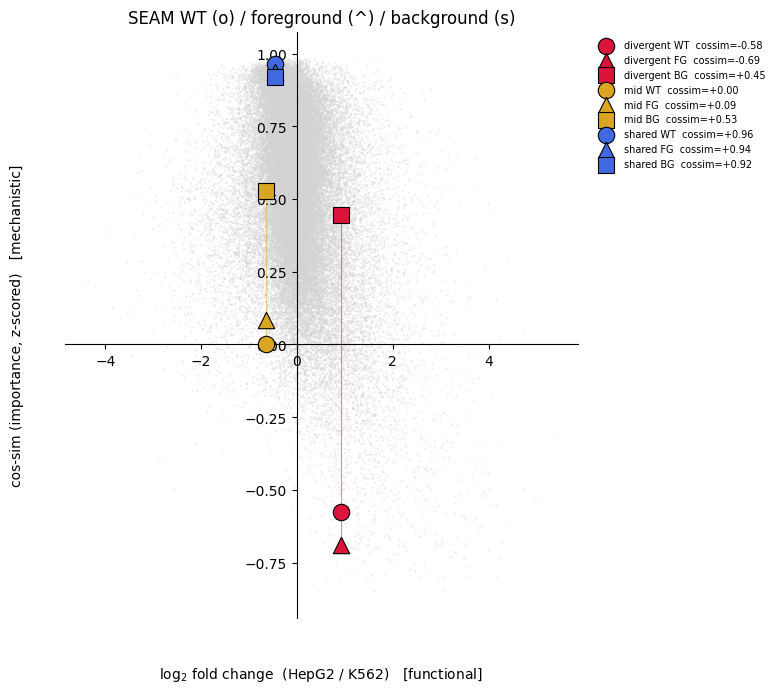

In [7]:
## SEAM foreground / background / WT for the 3 picks on the (lfc, cossim) plane.
## SEAM saves *hypothetical* attributions (mean-centered across channels), so we must
## project through the WT OHE first to match em.cosine_similarity(mode='importance').
## WT cossim still uses the global cossim[seq_i] for consistency with the picking cell.
def hyp_ohe_cossim(seq_i, fname):
    ohe = em.X[seq_i, :, :ENH].numpy().T               # (230, 4)
    H = np.load(os.path.join(SEAM_DIR, 'HepG2', str(seq_i), fname)) * ohe
    K = np.load(os.path.join(SEAM_DIR, 'K562',  str(seq_i), fname)) * ohe
    iH = H.sum(axis=1); iK = K.sum(axis=1)
    iH = (iH - iH.mean()) / (iH.std() + 1e-12)
    iK = (iK - iK.mean()) / (iK.std() + 1e-12)
    return float((iH * iK).sum() / (np.linalg.norm(iH) * np.linalg.norm(iK) + 1e-12))

def fg_bg_cossim(seq_i):
    return {'WT': float(cossim[seq_i]),
            'FG': hyp_ohe_cossim(seq_i, 'foreground_scaled.npy'),
            'BG': hyp_ohe_cossim(seq_i, 'average_background_scaled.npy')}

PICK_TAGS = [(lo_seq, 'divergent', 'crimson'),
             (mid_seq, 'mid',      'goldenrod'),
             (hi_seq, 'shared',    'royalblue')]
MARKERS = {'WT': 'o', 'FG': '^', 'BG': 's'}

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(lfc[fin], cossim[fin], s=2, c='lightgray', alpha=0.4,
           edgecolors='none', rasterized=True)

for seq_i, tag, color in PICK_TAGS:
    cs_by = fg_bg_cossim(seq_i)
    print(f'{tag:9s} idx={seq_i}  lfc={lfc[seq_i]:+.2f}   '
          f'WT={cs_by["WT"]:+.3f}  FG={cs_by["FG"]:+.3f}  BG={cs_by["BG"]:+.3f}')
    for kind, m in MARKERS.items():
        ax.scatter(lfc[seq_i], cs_by[kind], s=140, c=color, marker=m,
                   edgecolors='k', lw=0.8, zorder=5,
                   label=f'{tag} {kind}  cossim={cs_by[kind]:+.2f}')
    ax.plot([lfc[seq_i]] * 3, [cs_by['BG'], cs_by['WT'], cs_by['FG']],
            '-', color=color, lw=0.8, alpha=0.5, zorder=4)

ax.spines['left'].set_position('zero'); ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_visible(False);    ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('bottom');  ax.yaxis.set_ticks_position('left')
ax.set_xlabel('log$_2$ fold change  (HepG2 / K562)   [functional]')
ax.set_ylabel('cos-sim (importance, z-scored)   [mechanistic]')
ax.xaxis.set_label_coords(0.5, -0.08); ax.yaxis.set_label_coords(-0.08, 0.5)
ax.set_title('SEAM WT (o) / foreground (^) / background (s)')
ax.legend(frameon=False, fontsize=7, loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()

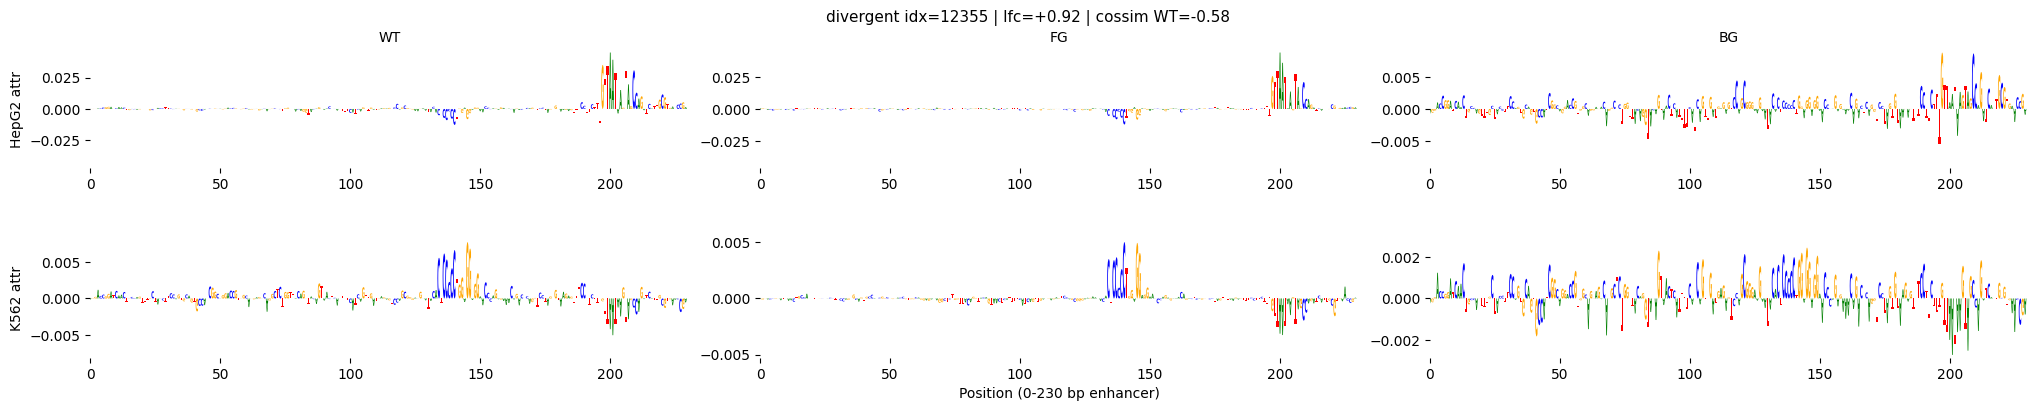

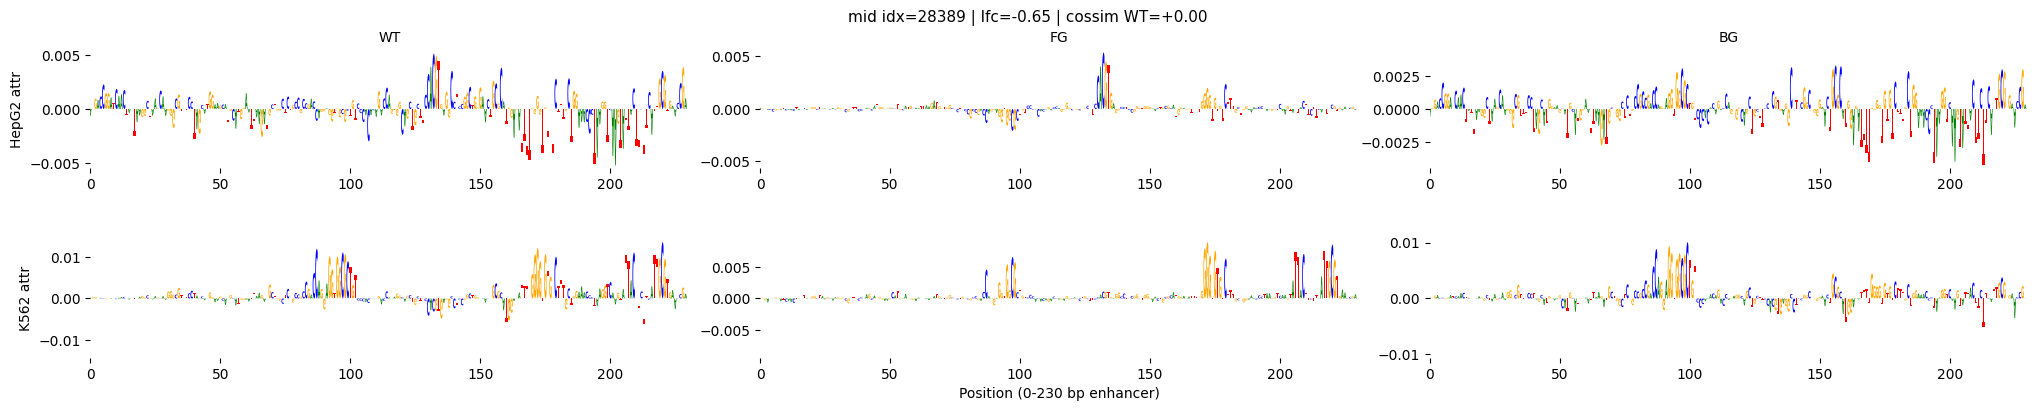

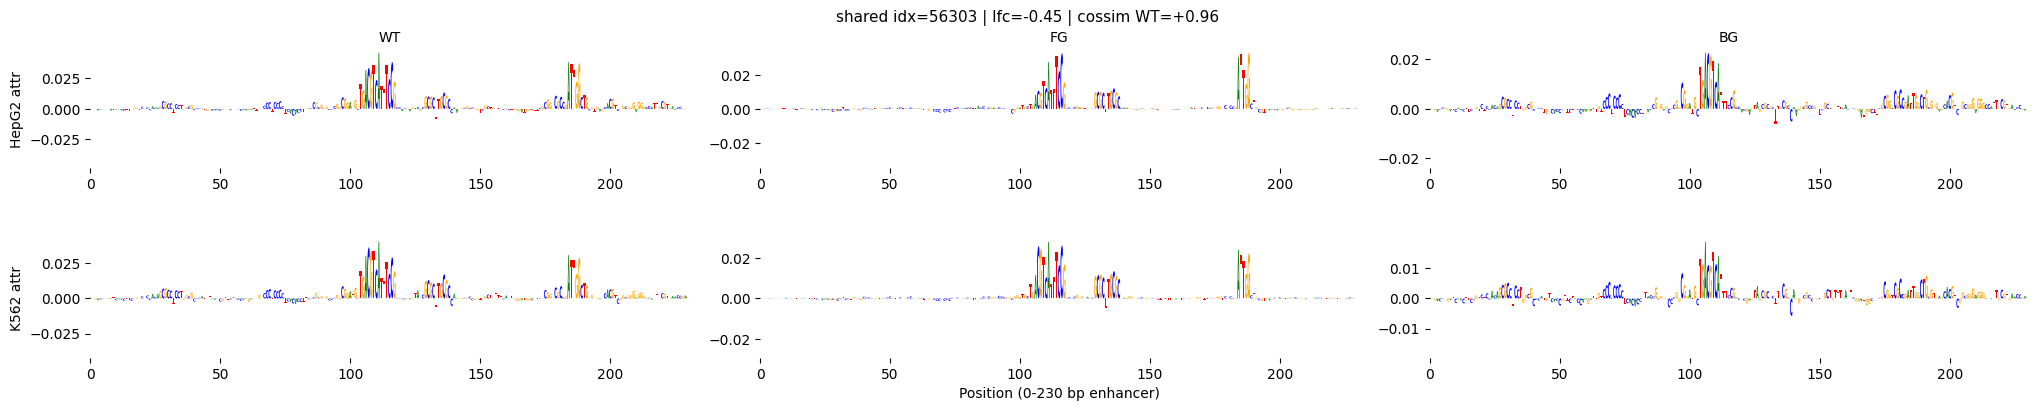

In [8]:
## WT / FG / BG attribution logos for each pick (HepG2 row, K562 row).
## Each subplot scaled to its own |max| -- magnitudes differ a lot between WT and FG/BG.
## SEAM maps are hypothetical -> project through WT OHE for visualization.
KINDS = [('WT', 'wt_attribution.npy'),
         ('FG', 'foreground_scaled.npy'),
         ('BG', 'average_background_scaled.npy')]

for seq_i, tag, _ in PICK_TAGS:
    ohe = em.X[seq_i, :, :ENH].numpy().T               # (230, 4)
    fig, axes = plt.subplots(2, 3, figsize=(25, 4),
                             gridspec_kw={'hspace': 0.6, 'wspace': 0.12})
    for ci, ct in enumerate(['HepG2', 'K562']):
        for ki, (kind, fname) in enumerate(KINDS):
            m = np.load(os.path.join(SEAM_DIR, ct, str(seq_i), fname)) * ohe
            ax = axes[ci, ki]
            yabs = max(abs(m).max() * 1.05, 1e-6)
            fast_logo(m.T, ax=ax, ylim=(-yabs, yabs))
            ax.set_xlim(0, ENH)
            for sp in ax.spines.values(): sp.set_visible(False)
            if ci == 0: ax.set_title(kind, fontsize=10)
            if ki == 0: ax.set_ylabel(f'{ct} attr')
    axes[1, 1].set_xlabel(f'Position (0-{ENH} bp enhancer)')
    fig.suptitle(f'{tag} idx={seq_i} | lfc={lfc[seq_i]:+.2f} | cossim WT={cossim[seq_i]:+.2f}',
                 fontsize=11)
    plt.show()

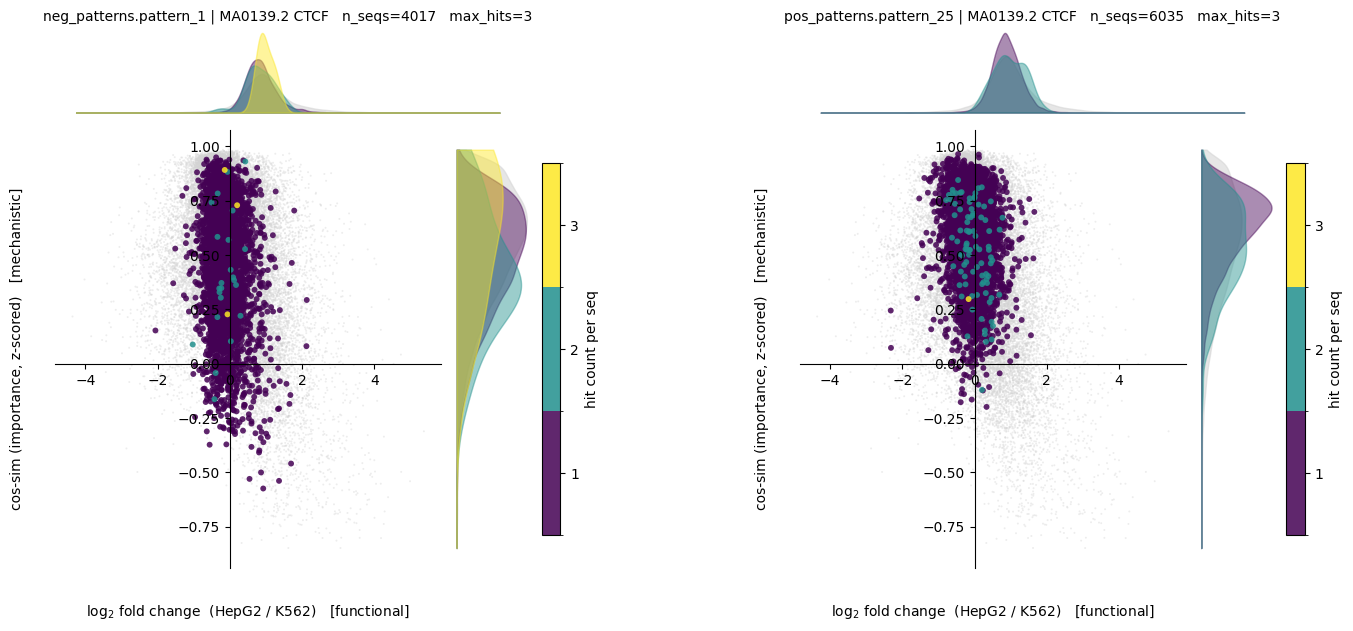

In [9]:
## One panel per HepG2 CTCF pattern -- color = integer hit count of that pattern, KDE marginals.
from matplotlib.colors import BoundaryNorm
from scipy.stats import gaussian_kde

ct = 'HepG2'
pats = CTCF_PATTERNS[ct]

fig = plt.figure(figsize=(8.5 * len(pats), 7))
outer = fig.add_gridspec(1, len(pats), wspace=0.3)

for col, pat in enumerate(pats):
    ann = ctcf_match[(ct, pat)]
    h = hits[ct][hits[ct]['motif_name'] == pat]
    n_per = h.groupby('peak_id').size()
    seqs = n_per.index.values.astype(int)
    n_h = n_per.values
    keep = fin[seqs]
    seqs, n_h = seqs[keep], n_h[keep]

    n_max  = int(n_h.max()) if len(n_h) else 1
    counts = np.arange(1, n_max + 1)
    norm   = BoundaryNorm(np.arange(0.5, n_max + 1.5), ncolors=plt.cm.viridis.N)
    cmap   = plt.cm.viridis

    gs = outer[col].subgridspec(2, 2, width_ratios=(5, 1), height_ratios=(1, 5),
                                wspace=0.05, hspace=0.05)
    ax     = fig.add_subplot(gs[1, 0])
    ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_rgt = fig.add_subplot(gs[1, 1], sharey=ax)

    ax.scatter(lfc[fin], cossim[fin], s=2, c='lightgray', alpha=0.4,
               edgecolors='none', rasterized=True)
    order = np.argsort(n_h)
    sc = ax.scatter(lfc[seqs[order]], cossim[seqs[order]], c=n_h[order],
                    cmap=cmap, norm=norm, s=18, alpha=0.85,
                    edgecolors='none', rasterized=True)
    fig.colorbar(sc, ax=[ax, ax_rgt], ticks=counts, format='%d', pad=0.02,
                 shrink=0.85, label='hit count per seq')

    xs = np.linspace(np.nanmin(lfc[fin]),    np.nanmax(lfc[fin]),    400)
    ys = np.linspace(np.nanmin(cossim[fin]), np.nanmax(cossim[fin]), 400)
    ax_top.fill_between(xs, gaussian_kde(lfc[fin])(xs),    color='lightgray', alpha=0.55)
    ax_rgt.fill_betweenx(ys, gaussian_kde(cossim[fin])(ys), color='lightgray', alpha=0.55)
    for c in counts:
        sel = seqs[n_h == c]
        if len(sel) < 2: continue
        color = cmap(norm(c))
        ax_top.fill_between(xs, gaussian_kde(lfc[sel])(xs),    color=color, alpha=0.45)
        ax_rgt.fill_betweenx(ys, gaussian_kde(cossim[sel])(ys), color=color, alpha=0.45)

    ax.spines['left'].set_position('zero'); ax.spines['bottom'].set_position('zero')
    ax.spines['top'].set_visible(False);    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom');  ax.yaxis.set_ticks_position('left')
    ax.set_xlabel('log$_2$ fold change  (HepG2 / K562)   [functional]')
    ax.set_ylabel('cos-sim (importance, z-scored)   [mechanistic]')
    ax.xaxis.set_label_coords(0.5, -0.08); ax.yaxis.set_label_coords(-0.08, 0.5)
    ax_top.set_title(f'{pat} | {ann}   n_seqs={len(seqs)}   max_hits={n_max}', fontsize=10)
    for a in (ax_top, ax_rgt):
        a.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for sp in a.spines.values(): sp.set_visible(False)

plt.show()

neg_patterns.pattern_1 | MA0139.2 CTCF  -> idx=37695  cossim=+0.226  lfc=-0.07
pos_patterns.pattern_25 | MA0139.2 CTCF  -> idx=1452  cossim=+0.297  lfc=-0.17


/tmp/slurm_tmp/2078086/ipykernel_3730339/1379671115.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


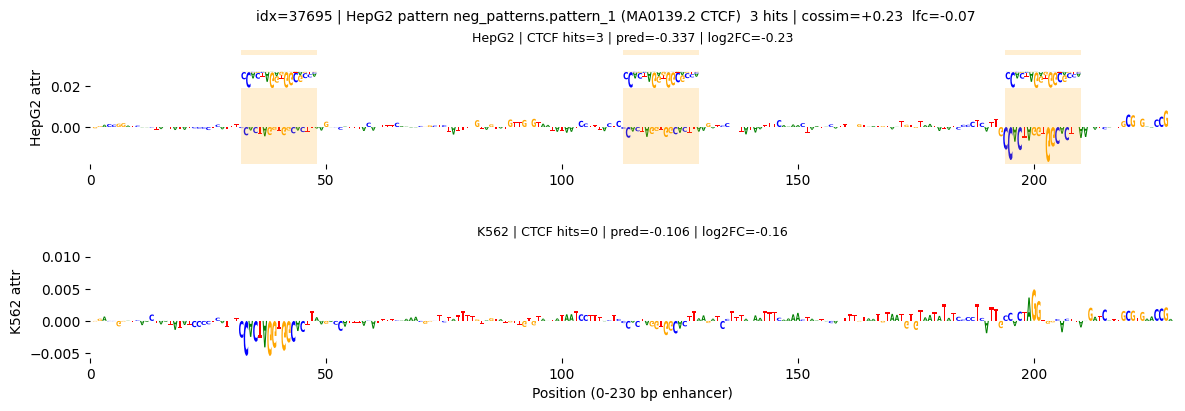

/tmp/slurm_tmp/2078086/ipykernel_3730339/1379671115.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


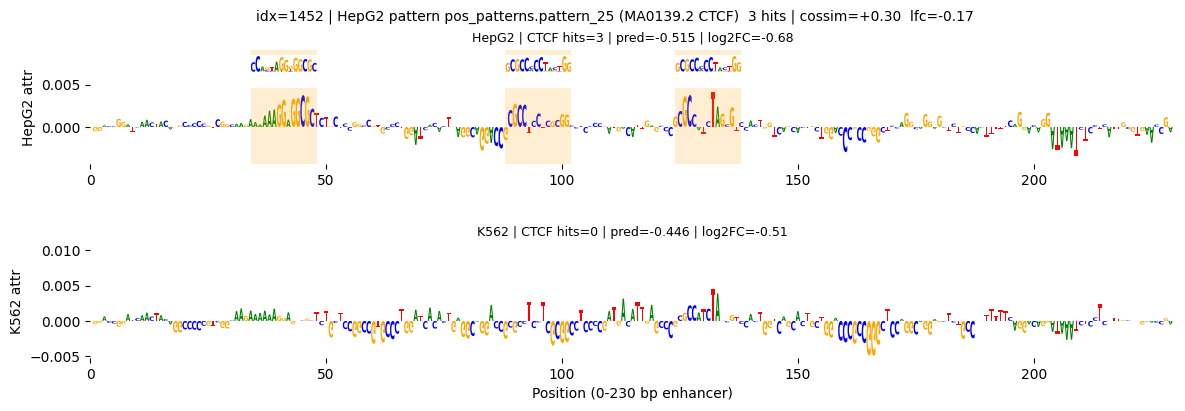

In [10]:
## Example seq per HepG2 CTCF pattern with exactly 3 hits -- show both HepG2 and K562 attr.
## Per-ct convention: each row highlights only that ct's own CTCF hits (any CTCF pattern of that ct).
ct_pick = 'HepG2'
N_HITS = 3
ORDER = ['HepG2', 'K562']

picks_3 = {}
for pat in CTCF_PATTERNS[ct_pick]:
    h = hits[ct_pick][hits[ct_pick]['motif_name'] == pat]
    n_per = h.groupby('peak_id').size()
    cand = n_per[n_per == N_HITS].index.values.astype(int)
    cand = cand[fin[cand]]
    if len(cand) == 0:
        print(f'{pat}: no seq with exactly {N_HITS} hits'); continue
    picks_3[pat] = int(cand[np.abs(cossim[cand]).argmin()])
    print(f'{pat} | {ctcf_match[(ct_pick, pat)]}  -> idx={picks_3[pat]}  '
          f'cossim={cossim[picks_3[pat]]:+.3f}  lfc={lfc[picks_3[pat]]:+.2f}')

for pat, seq_i in picks_3.items():
    peak_start = int(df['start_hg38'].fillna(0).iloc[seq_i])
    fig, axes = plt.subplots(len(ORDER), 1, figsize=(14, 2.0 * len(ORDER)),
                             gridspec_kw={'hspace': 0.7})
    for ri, ct in enumerate(ORDER):
        a = em.attr[ct][seq_i, :, :ENH]
        yabs = abs(a).max() * 1.05
        ax = axes[ri]
        fast_logo(a, ax=ax, ylim=(-yabs, yabs * 2.1))

        h = hits[ct][(hits[ct]['peak_id'] == seq_i) &
                     (hits[ct]['motif_name'].isin(CTCF_PATTERNS[ct]))].copy()
        h['x0'] = h['start'].astype(int) - peak_start
        h['x1'] = h['end'].astype(int)   - peak_start

        for k, hit in h.iterrows():
            ax.axvspan(hit['x0'], hit['x1'], color='orange', alpha=0.18, lw=0)
            cwm = trim_cwm(get_cwm_obj(ct, hit['motif_name']))
            if hit['strand'] == '-': cwm = cwm[::-1, ::-1]
            w = max(hit['x1'] - hit['x0'], 1)
            ins = ax.inset_axes([hit['x0'], yabs * 1.05, w, yabs * 0.9],
                                transform=ax.transData)
            cy = max(abs(cwm).max() * 1.05, 1e-6)
            fast_logo(cwm.T, ax=ins, ylim=(-cy, cy))
            ins.set_xticks([]); ins.set_yticks([])
            for sp in ins.spines.values(): sp.set_visible(False)

        ax.set_title(f'{ct} | CTCF hits={len(h)} | pred={em.predictions[ct][seq_i]:.3f} | '
                     f'log2FC={df[f"{ct}_log2FC"].iloc[seq_i]:+.2f}', fontsize=9)
        ax.set_ylabel(f'{ct} attr')
        ax.set_xlim(0, ENH)
        for sp in ax.spines.values(): sp.set_visible(False)
    axes[-1].set_xlabel(f'Position (0-{ENH} bp enhancer)')
    fig.suptitle(f'idx={seq_i} | HepG2 pattern {pat} ({ctcf_match[(ct_pick, pat)]})  3 hits | '
                 f'cossim={cossim[seq_i]:+.2f}  lfc={lfc[seq_i]:+.2f}', fontsize=10)
    plt.tight_layout(); plt.show()

15293 CTCF-hit seqs   overlap distribution: mean=0.40  zero=8783  one=5631


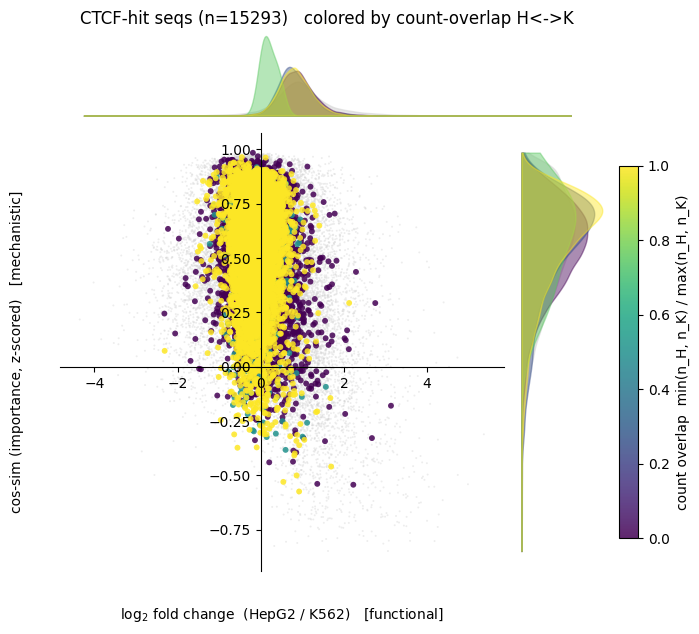

In [11]:
## CTCF-hit seqs on (lfc, cossim), colored by HepG2/K562 hit-count overlap (count-based, not positional).
##   overlap = min(n_hep, n_k) / max(n_hep, n_k)   -> 0 = called only in one ct, 1 = same count in both.
from scipy.stats import gaussian_kde

cnt_hep = (hits['HepG2'].loc[hits['HepG2']['motif_name'].isin(CTCF_PATTERNS['HepG2'])]
           .groupby('peak_id').size())
cnt_k   = (hits['K562'].loc[hits['K562']['motif_name'].isin(CTCF_PATTERNS['K562'])]
           .groupby('peak_id').size())
all_seqs = sorted(set(cnt_hep.index) | set(cnt_k.index))
seqs = np.array(all_seqs, dtype=int)
seqs = seqs[fin[seqs]]
n_h = cnt_hep.reindex(seqs).fillna(0).astype(int).values
n_k = cnt_k.reindex(seqs).fillna(0).astype(int).values
denom = np.maximum(n_h, n_k)
overlap = np.where(denom > 0, np.minimum(n_h, n_k) / denom, 0)
print(f'{len(seqs)} CTCF-hit seqs   overlap distribution: '
      f'mean={overlap.mean():.2f}  zero={(overlap==0).sum()}  one={(overlap==1).sum()}')

cmap = plt.cm.viridis
fig = plt.figure(figsize=(8.5, 7))
gs = fig.add_gridspec(2, 2, width_ratios=(5, 1), height_ratios=(1, 5),
                      wspace=0.05, hspace=0.05)
ax     = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
ax_rgt = fig.add_subplot(gs[1, 1], sharey=ax)

ax.scatter(lfc[fin], cossim[fin], s=2, c='lightgray', alpha=0.4,
           edgecolors='none', rasterized=True)
order = np.argsort(overlap)
sc = ax.scatter(lfc[seqs[order]], cossim[seqs[order]], c=overlap[order],
                cmap=cmap, vmin=0, vmax=1, s=18, alpha=0.85,
                edgecolors='none', rasterized=True)
fig.colorbar(sc, ax=[ax, ax_rgt], pad=0.02, shrink=0.85,
             label='count overlap  min(n_H, n_K) / max(n_H, n_K)')

xs = np.linspace(np.nanmin(lfc[fin]),    np.nanmax(lfc[fin]),    400)
ys = np.linspace(np.nanmin(cossim[fin]), np.nanmax(cossim[fin]), 400)
ax_top.fill_between(xs, gaussian_kde(lfc[fin])(xs),    color='lightgray', alpha=0.55)
ax_rgt.fill_betweenx(ys, gaussian_kde(cossim[fin])(ys), color='lightgray', alpha=0.55)

bins = [(-1e-9, 0.0001, 'no overlap'),
        (0.0001, 0.5,   '<50%'),
        (0.5,    0.999, '50-99%'),
        (0.999,  1.001, 'full')]
for lo, hi, label in bins:
    sel = seqs[(overlap > lo) & (overlap <= hi)]
    if len(sel) < 2: continue
    color = cmap((lo + min(hi, 1)) / 2)
    ax_top.fill_between(xs, gaussian_kde(lfc[sel])(xs),    color=color, alpha=0.45)
    ax_rgt.fill_betweenx(ys, gaussian_kde(cossim[sel])(ys), color=color, alpha=0.45)

ax.spines['left'].set_position('zero'); ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_visible(False);    ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('bottom');  ax.yaxis.set_ticks_position('left')
ax.set_xlabel('log$_2$ fold change  (HepG2 / K562)   [functional]')
ax.set_ylabel('cos-sim (importance, z-scored)   [mechanistic]')
ax.xaxis.set_label_coords(0.5, -0.08); ax.yaxis.set_label_coords(-0.08, 0.5)
ax_top.set_title(f'CTCF-hit seqs (n={len(seqs)})   colored by count-overlap H<->K')
for a in (ax_top, ax_rgt):
    a.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for sp in a.spines.values(): sp.set_visible(False)
plt.show()

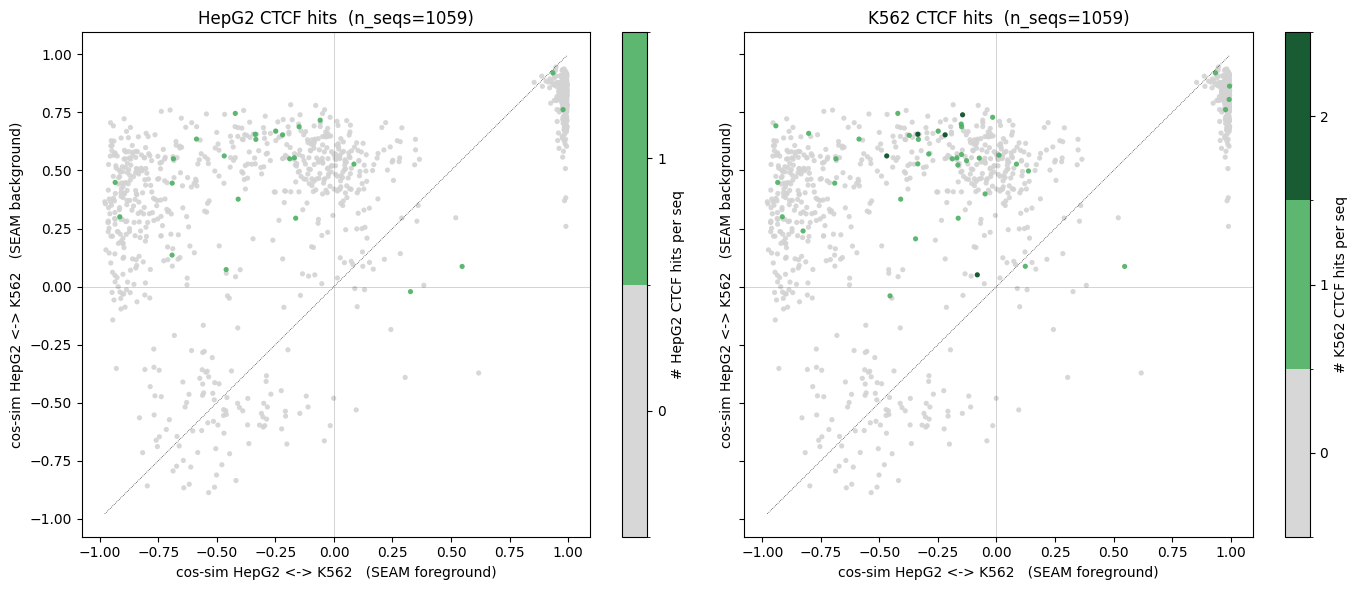

In [12]:
## Mech x mech space: FG H<->K cossim (x) vs BG H<->K cossim (y).
## One panel per ct, color = that ct's CTCF hit count (own patterns), integer-discrete.
## 0 hits -> gray; 1+ hits -> darker green gradient (no faint shades).
from matplotlib.colors import BoundaryNorm, ListedColormap

all_idx = seam_idx                                          # ~1059 SEAM seqs
ohe_all = em.X[all_idx, :, :ENH].numpy().transpose(0, 2, 1) # (N, 230, 4)

def cossim_HK(seqs_idx, fname):
    out = np.full(len(seqs_idx), np.nan)
    for i, si in enumerate(seqs_idx):
        H = np.load(os.path.join(SEAM_DIR, 'HepG2', str(si), fname)) * ohe_all[i]
        K = np.load(os.path.join(SEAM_DIR, 'K562',  str(si), fname)) * ohe_all[i]
        iH = H.sum(axis=1); iK = K.sum(axis=1)
        iH = (iH - iH.mean()) / (iH.std() + 1e-12)
        iK = (iK - iK.mean()) / (iK.std() + 1e-12)
        out[i] = (iH * iK).sum() / (np.linalg.norm(iH) * np.linalg.norm(iK) + 1e-12)
    return out

cos_fg_all = cossim_HK(all_idx, 'foreground_scaled.npy')
cos_bg_all = cossim_HK(all_idx, 'average_background_scaled.npy')
fin_seam = np.isfinite(cos_fg_all) & np.isfinite(cos_bg_all)
lo = min(np.nanmin(cos_fg_all[fin_seam]), np.nanmin(cos_bg_all[fin_seam]))
hi = max(np.nanmax(cos_fg_all[fin_seam]), np.nanmax(cos_bg_all[fin_seam]))

n_ctcf = {}
for ct in ('HepG2', 'K562'):
    cnt = (hits[ct].loc[hits[ct]['motif_name'].isin(CTCF_PATTERNS[ct])]
           .groupby('peak_id').size())
    n_ctcf[ct] = cnt.reindex(all_idx).fillna(0).astype(int).values

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, ct in zip(axes, ('HepG2', 'K562')):
    n = n_ctcf[ct]
    n_max = int(n[fin_seam].max()) if fin_seam.any() else 1
    cmap = ListedColormap(['lightgray',
                           *plt.cm.Greens(np.linspace(0.6, 0.98, max(n_max, 1)))])
    norm = BoundaryNorm(np.arange(-0.5, n_max + 1.5), ncolors=cmap.N)
    order = np.argsort(n[fin_seam])
    idx_f = np.where(fin_seam)[0][order]
    sc = ax.scatter(cos_fg_all[idx_f], cos_bg_all[idx_f], c=n[idx_f],
                    cmap=cmap, norm=norm, s=14, alpha=0.9, edgecolors='none')
    ax.plot([lo, hi], [lo, hi], 'k:', lw=0.5)
    ax.axhline(0, color='k', lw=0.4, alpha=0.3); ax.axvline(0, color='k', lw=0.4, alpha=0.3)
    ax.set_xlabel('cos-sim HepG2 <-> K562   (SEAM foreground)')
    ax.set_ylabel('cos-sim HepG2 <-> K562   (SEAM background)')
    ax.set_title(f'{ct} CTCF hits  (n_seqs={fin_seam.sum()})')
    plt.colorbar(sc, ax=ax, ticks=np.arange(0, n_max + 1), format='%d',
                 label=f'# {ct} CTCF hits per seq')
plt.tight_layout(); plt.show()

top patterns by hit count within SEAM library:
  K562  neg_patterns.pattern_5     n=   754  ann=MA0153.2 HNF1B
  HepG2  pos_patterns.pattern_5     n=   731  ann=MA0153.2 HNF1B
  HepG2  pos_patterns.pattern_1     n=   336  ann=MA0484.3 HNF4G
  K562  pos_patterns.pattern_1     n=   321  ann=MA0076.3 ELK4
  HepG2  pos_patterns.pattern_3     n=   307  ann=MA0076.3 ELK4
  K562  neg_patterns.pattern_1     n=   250  ann=MA1527.2 NFIC
  K562  pos_patterns.pattern_0     n=   246  ann=MA2681.1 KLF8
  HepG2  pos_patterns.pattern_0     n=   240  ann=MA2681.1 KLF8
  HepG2  pos_patterns.pattern_13    n=   215  ann=MA0846.2 FOXC2
  HepG2  pos_patterns.pattern_4     n=   181  ann=MA0060.4 NFYA


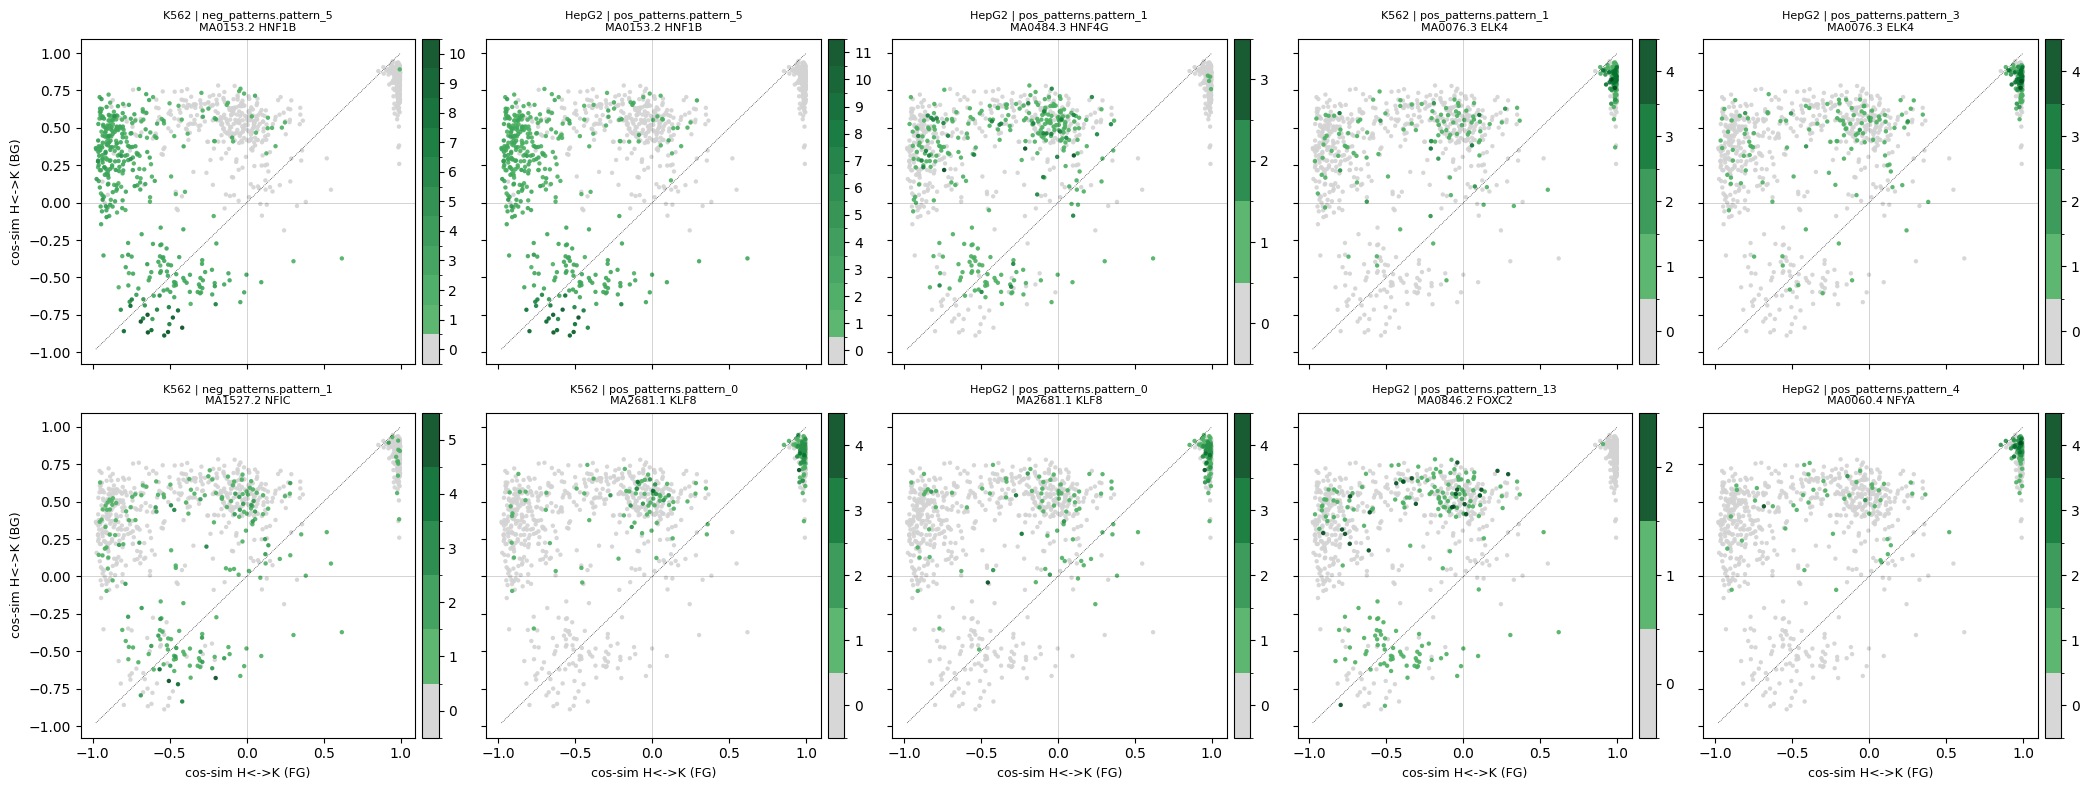

In [13]:
## Same FG-vs-BG cossim space, one panel per top-10 (ct, pattern) by hit count.
## Top-10 ranked by hits ONLY within the 1059-seq SEAM library (not all 56k).
TOP_K = 10
seam_set_int = set(int(s) for s in all_idx)

pat_counts = []
for ct in ('HepG2', 'K562'):
    sub = hits[ct][hits[ct]['peak_id'].isin(seam_set_int)]
    for m, n in sub['motif_name'].value_counts().items():
        pat_counts.append((ct, m, int(n)))
pat_counts.sort(key=lambda r: -r[2])
top = pat_counts[:TOP_K]
print('top patterns by hit count within SEAM library:')
for ct, m, n in top:
    print(f'  {ct}  {m:25s}  n={n:6d}  ann={tomtom.get(f"{ct}/{m}", "?")}')

ncol = 5
nrow = (TOP_K + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 4.0 * nrow),
                         sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for k, (ct, m, _) in enumerate(top):
    ax = axes[k]
    cnt = hits[ct][hits[ct]['motif_name'] == m].groupby('peak_id').size()
    n = cnt.reindex(all_idx).fillna(0).astype(int).values
    n_max = int(n[fin_seam].max()) if fin_seam.any() else 1
    if n_max == 0: n_max = 1
    cmap = ListedColormap(['lightgray',
                           *plt.cm.Greens(np.linspace(0.6, 0.98, n_max))])
    norm = BoundaryNorm(np.arange(-0.5, n_max + 1.5), ncolors=cmap.N)
    order = np.argsort(n[fin_seam])
    idx_f = np.where(fin_seam)[0][order]
    sc = ax.scatter(cos_fg_all[idx_f], cos_bg_all[idx_f], c=n[idx_f],
                    cmap=cmap, norm=norm, s=10, alpha=0.9, edgecolors='none')
    ax.plot([lo, hi], [lo, hi], 'k:', lw=0.5)
    ax.axhline(0, color='k', lw=0.4, alpha=0.3); ax.axvline(0, color='k', lw=0.4, alpha=0.3)
    ann = tomtom.get(f'{ct}/{m}', '?')
    ax.set_title(f'{ct} | {m}\n{ann}', fontsize=8)
    plt.colorbar(sc, ax=ax, ticks=np.arange(0, n_max + 1), format='%d',
                 fraction=0.046, pad=0.02)

for k in range(len(top), len(axes)):
    axes[k].axis('off')
for ax in axes[-ncol:]:
    ax.set_xlabel('cos-sim H<->K (FG)', fontsize=9)
for ax in axes[::ncol]:
    ax.set_ylabel('cos-sim H<->K (BG)', fontsize=9)

plt.tight_layout(); plt.show()

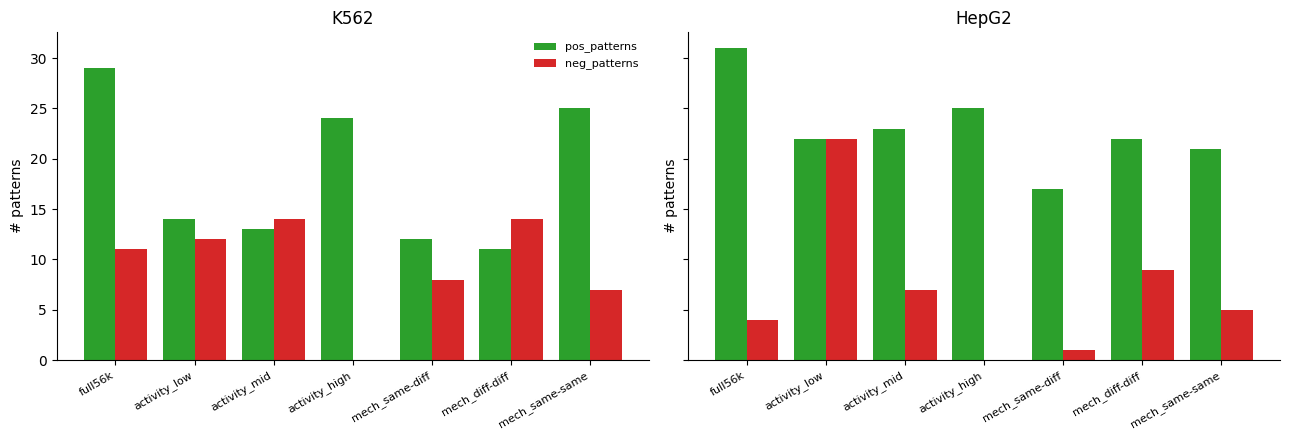


per-condition pattern totals:
  K562   full56k             pos= 29  neg= 11
  K562   activity_low        pos= 14  neg= 12
  K562   activity_mid        pos= 13  neg= 14
  K562   activity_high       pos= 24  neg=  0
  K562   mech_same-diff      pos= 12  neg=  8
  K562   mech_diff-diff      pos= 11  neg= 14
  K562   mech_same-same      pos= 25  neg=  7
  HepG2  full56k             pos= 31  neg=  4
  HepG2  activity_low        pos= 22  neg= 22
  HepG2  activity_mid        pos= 23  neg=  7
  HepG2  activity_high       pos= 25  neg=  0
  HepG2  mech_same-diff      pos= 17  neg=  1
  HepG2  mech_diff-diff      pos= 22  neg=  9
  HepG2  mech_same-same      pos= 21  neg=  5


In [14]:
## Pattern enrichment per modisco condition: # pos / # neg patterns discovered per
## (ct, condition). Loads any {ct}_*_enh{ENH}_default.h5 in modisco dir.
import glob, re

CONDITIONS = ['full56k',
              'activity_low', 'activity_mid', 'activity_high',
              'mech_same-diff', 'mech_diff-diff', 'mech_same-same']

counts = {ct: {c: {'pos': 0, 'neg': 0, 'present': False} for c in CONDITIONS} for ct in CT}
for ct in CT:
    for cond in CONDITIONS:
        h5p = os.path.join(MODISCO_DIR, f'{ct}_{cond}_enh{ENH}_default.h5')
        if not os.path.exists(h5p): continue
        with h5py.File(h5p) as f:
            counts[ct][cond]['pos'] = len(f['pos_patterns']) if 'pos_patterns' in f else 0
            counts[ct][cond]['neg'] = len(f['neg_patterns']) if 'neg_patterns' in f else 0
            counts[ct][cond]['present'] = True

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
x = np.arange(len(CONDITIONS))
w = 0.4
for ax, ct in zip(axes, CT):
    pos = [counts[ct][c]['pos'] for c in CONDITIONS]
    neg = [counts[ct][c]['neg'] for c in CONDITIONS]
    ax.bar(x - w/2, pos, w, color='#2ca02c', label='pos_patterns')
    ax.bar(x + w/2, neg, w, color='#d62728', label='neg_patterns')
    for i, c in enumerate(CONDITIONS):
        if not counts[ct][c]['present']:
            ax.text(i, 0.2, 'pending', ha='center', va='bottom',
                    fontsize=8, color='gray', rotation=90)
    ax.set_xticks(x); ax.set_xticklabels(CONDITIONS, rotation=30, ha='right', fontsize=8)
    ax.set_title(ct); ax.set_ylabel('# patterns')
    for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
axes[0].legend(frameon=False, fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

print('\nper-condition pattern totals:')
for ct in CT:
    for cond in CONDITIONS:
        c = counts[ct][cond]
        tag = '' if c['present'] else '  (h5 not yet present)'
        print(f'  {ct:5s}  {cond:18s}  pos={c["pos"]:3d}  neg={c["neg"]:3d}{tag}')

stratum sizes: {'same-diff': 353, 'diff-diff': 353, 'same-same': 353}


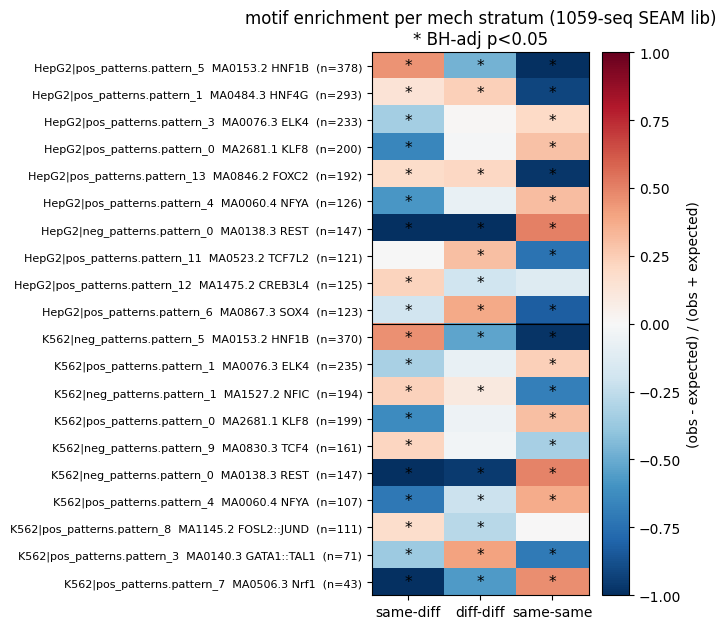

In [15]:
## Motif-hit enrichment across mech strata (same-diff / diff-diff / same-same)
## within the 1059 SEAM-library seqs. Hits = full-lib finemo calls per pattern.
## Score = (obs - expected) / (obs + expected), bounded in [-1, 1]:
##   -1 = fully depleted, 0 = at lib average, +1 = fully enriched.
## Rows ordered: all HepG2 patterns first, then K562 (each block sorted by count desc).
## * = Fisher exact p<0.05 (BH-adj).
from scipy.stats import fisher_exact

def bh_adjust(p):
    p = np.asarray(p, float); n = len(p); o = np.argsort(p)
    ranked = p[o] * n / np.arange(1, n + 1)
    cum = np.minimum.accumulate(ranked[::-1])[::-1]
    adj = np.empty(n); adj[o] = np.clip(cum, 0, 1)
    return adj

cs_lib = cossim[all_idx]
order_lib = np.argsort(cs_lib)
n_lib = len(all_idx)
edges = [0, n_lib // 3, 2 * n_lib // 3, n_lib]
STRATA = ['same-diff', 'diff-diff', 'same-same']
strat_idx = {STRATA[i]: set(int(all_idx[j]) for j in order_lib[edges[i]:edges[i+1]])
             for i in range(3)}
print('stratum sizes:', {k: len(v) for k, v in strat_idx.items()})

TOP_N_PER_CT = 10
seam_set_int = set(int(s) for s in all_idx)
top_pats = []
for ct in ('HepG2', 'K562'):
    sub = hits[ct][hits[ct]['peak_id'].isin(seam_set_int)]
    for m, n in sub['motif_name'].value_counts().head(TOP_N_PER_CT).items():
        top_pats.append((ct, m, int(n)))

rows = []
for ct, m, _ in top_pats:
    seqs_with = set(int(p) for p in
                    hits[ct].loc[hits[ct]['motif_name'] == m, 'peak_id'].unique())
    seqs_with_lib = seqs_with & seam_set_int
    K = len(seqs_with_lib)
    rec = {'pat': f'{ct}|{m}', 'ann': tomtom.get(f"{ct}/{m}", '?'), 'n_lib': K}
    for s in STRATA:
        S = strat_idx[s]
        n = len(S)
        k = len(seqs_with_lib & S)
        expected = K * n / n_lib if n_lib > 0 else 0
        denom = k + expected
        rec[f'{s}_obs'] = k
        rec[f'{s}_score'] = (k - expected) / denom if denom > 0 else 0.0
        a, b = k, n - k
        c = K - k; d = (n_lib - n) - c
        rec[f'{s}_p'] = fisher_exact([[a, b], [c, d]])[1]
    rows.append(rec)
M = pd.DataFrame(rows)

for s in STRATA:
    M[f'{s}_padj'] = bh_adjust(M[f'{s}_p'].values)

score_mat = M[[f'{s}_score' for s in STRATA]].values
sig_mat   = M[[f'{s}_padj'  for s in STRATA]].values < 0.05
labels    = [f'{r["pat"]}  {r["ann"]}  (n={r["n_lib"]})' for _, r in M.iterrows()]

fig, ax = plt.subplots(figsize=(6.8, max(4, 0.32 * len(M))))
im = ax.imshow(score_mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(STRATA))); ax.set_xticklabels(STRATA)
ax.set_yticks(range(len(M)));      ax.set_yticklabels(labels, fontsize=8)
for i in range(score_mat.shape[0]):
    for j in range(score_mat.shape[1]):
        if sig_mat[i, j]:
            ax.text(j, i, '*', ha='center', va='center', color='black', fontsize=11)
n_hep = int(M['pat'].str.startswith('HepG2|').sum())
ax.axhline(n_hep - 0.5, color='k', lw=0.8)
plt.colorbar(im, ax=ax, label='(obs - expected) / (obs + expected)')
ax.set_title(f'motif enrichment per mech stratum (1059-seq SEAM lib)\n* BH-adj p<0.05')
plt.tight_layout(); plt.show()

per-ct activity stratum sizes: {'K562': {'low': 18991, 'mid': 18992, 'high': 18992}, 'HepG2': {'low': 18991, 'mid': 18992, 'high': 18992}}


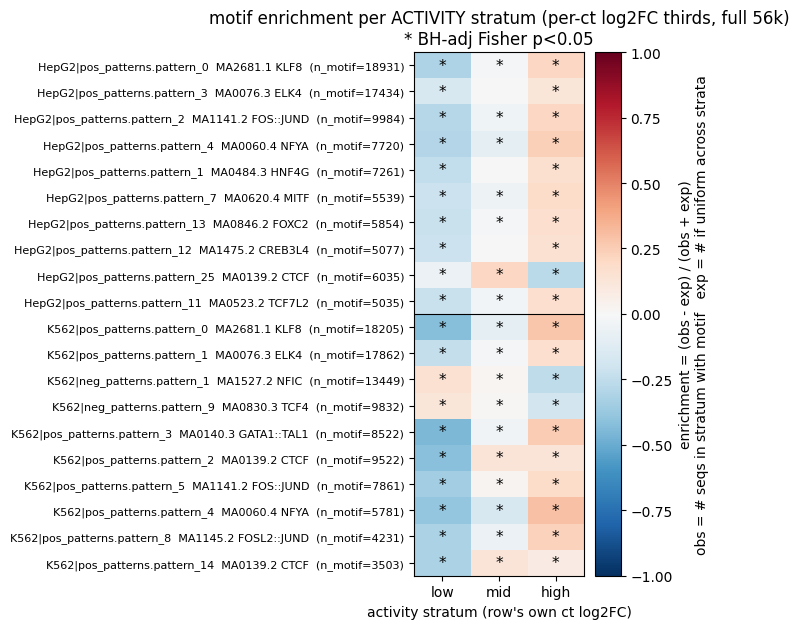

In [18]:
## Same heatmap, but stratified by per-ct activity (log2FC equal-thirds, full 56k lib).
## Each row's columns use THAT row's ct's own activity thirds (per-ct convention).
##
## For each (motif, stratum):
##   n_motif_in_stratum  = # seqs in this stratum that have the motif called   (observed)
##   n_motif_if_uniform  = # seqs we'd expect if the motif were spread evenly
##                         across strata = (total motif seqs) * (stratum size) / (lib size)
##   enrichment          = (obs - exp) / (obs + exp)   in [-1, +1]
##                         -1 = motif fully depleted from stratum
##                          0 = motif at library average
##                         +1 = motif fully concentrated in stratum
from scipy.stats import fisher_exact

ACT_STRATA = ['low', 'mid', 'high']

# per-ct activity thirds over the full library (matches run_modisco_activity.py)
act_strat_idx = {}
for ct in CT:
    act = df[f'{ct}_log2FC'].values
    order = np.argsort(act)
    n = len(order)
    edges = [0, n // 3, 2 * n // 3, n]
    act_strat_idx[ct] = {ACT_STRATA[i]: set(int(j) for j in order[edges[i]:edges[i+1]])
                         for i in range(3)}
print('per-ct activity stratum sizes:',
      {ct: {s: len(v) for s, v in d.items()} for ct, d in act_strat_idx.items()})

TOP_N_PER_CT = 10
top_pats = []
for ct in ('HepG2', 'K562'):
    for m, n in hits[ct]['motif_name'].value_counts().head(TOP_N_PER_CT).items():
        top_pats.append((ct, m, int(n)))

rows = []
n_lib = len(df)
for ct, m, _ in top_pats:
    motif_seqs = set(int(p) for p in
                     hits[ct].loc[hits[ct]['motif_name'] == m, 'peak_id'].unique())
    n_motif_total = len(motif_seqs)
    rec = {'pat': f'{ct}|{m}', 'ann': tomtom.get(f"{ct}/{m}", '?'), 'n_motif_total': n_motif_total}
    for s in ACT_STRATA:
        stratum = act_strat_idx[ct][s]
        n_stratum = len(stratum)
        n_motif_in_stratum = len(motif_seqs & stratum)
        n_motif_if_uniform = n_motif_total * n_stratum / n_lib
        denom = n_motif_in_stratum + n_motif_if_uniform
        rec[f'{s}_obs']        = n_motif_in_stratum
        rec[f'{s}_exp']        = n_motif_if_uniform
        rec[f'{s}_enrichment'] = ((n_motif_in_stratum - n_motif_if_uniform) / denom
                                  if denom > 0 else 0.0)
        # Fisher exact: motif-in-stratum vs motif-out-of-stratum, using all 56k as background
        a = n_motif_in_stratum
        b = n_stratum - a
        c = n_motif_total - a
        d = (n_lib - n_stratum) - c
        rec[f'{s}_p'] = fisher_exact([[a, b], [c, d]])[1]
    rows.append(rec)
M_act = pd.DataFrame(rows)

for s in ACT_STRATA:
    M_act[f'{s}_padj'] = bh_adjust(M_act[f'{s}_p'].values)

score_mat = M_act[[f'{s}_enrichment' for s in ACT_STRATA]].values
sig_mat   = M_act[[f'{s}_padj'       for s in ACT_STRATA]].values < 0.05
labels    = [f'{r["pat"]}  {r["ann"]}  (n_motif={r["n_motif_total"]})'
             for _, r in M_act.iterrows()]

fig, ax = plt.subplots(figsize=(6.8, max(4, 0.32 * len(M_act))))
im = ax.imshow(score_mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(ACT_STRATA))); ax.set_xticklabels(ACT_STRATA)
ax.set_yticks(range(len(M_act)));      ax.set_yticklabels(labels, fontsize=8)
for i in range(score_mat.shape[0]):
    for j in range(score_mat.shape[1]):
        if sig_mat[i, j]:
            ax.text(j, i, '*', ha='center', va='center', color='black', fontsize=11)
n_hep = int(M_act['pat'].str.startswith('HepG2|').sum())
ax.axhline(n_hep - 0.5, color='k', lw=0.8)
plt.colorbar(im, ax=ax,
             label='enrichment = (obs - exp) / (obs + exp)\n'
                   'obs = # seqs in stratum with motif   exp = # if uniform across strata')
ax.set_title('motif enrichment per ACTIVITY stratum (per-ct log2FC thirds, full 56k)\n'
             '* BH-adj Fisher p<0.05')
ax.set_xlabel('activity stratum (row\'s own ct log2FC)')
plt.tight_layout(); plt.show()

mech stratum sizes (full lib): {'same-diff': 18991, 'diff-diff': 18992, 'same-same': 18992}


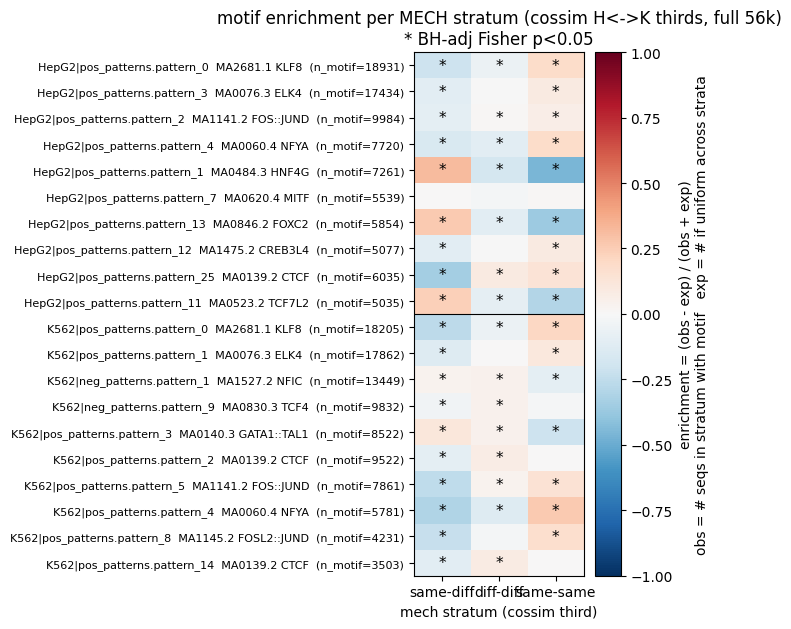

In [19]:
## Same heatmap, but stratified by mech (cossim H<->K) equal-thirds, full 56k lib.
## Matches run_modisco_mech.py: same-diff = bottom third, diff-diff = mid, same-same = top.
## Strata are shared across cts (cossim is symmetric).
##
## For each (motif, stratum):
##   n_motif_in_stratum  = # seqs in this stratum that have the motif called   (observed)
##   n_motif_if_uniform  = # seqs we'd expect if the motif were spread evenly
##                         across strata = (total motif seqs) * (stratum size) / (lib size)
##   enrichment          = (obs - exp) / (obs + exp)   in [-1, +1]
##                         -1 = motif fully depleted from stratum
##                          0 = motif at library average
##                         +1 = motif fully concentrated in stratum
from scipy.stats import fisher_exact

MECH_STRATA = ['same-diff', 'diff-diff', 'same-same']

# cossim thirds over the full library (matches run_modisco_mech.py)
order_full = np.argsort(np.where(fin, cossim, np.nan), kind='stable')
order_full = order_full[~np.isnan(np.take(np.where(fin, cossim, np.nan), order_full))]
n_lib = len(order_full)
edges = [0, n_lib // 3, 2 * n_lib // 3, n_lib]
mech_strat_idx = {MECH_STRATA[i]: set(int(j) for j in order_full[edges[i]:edges[i+1]])
                  for i in range(3)}
lib_set = set(int(j) for j in order_full)
print('mech stratum sizes (full lib):', {s: len(v) for s, v in mech_strat_idx.items()})

TOP_N_PER_CT = 10
top_pats = []
for ct in ('HepG2', 'K562'):
    for m, n in hits[ct]['motif_name'].value_counts().head(TOP_N_PER_CT).items():
        top_pats.append((ct, m, int(n)))

rows = []
for ct, m, _ in top_pats:
    motif_seqs = set(int(p) for p in
                     hits[ct].loc[hits[ct]['motif_name'] == m, 'peak_id'].unique())
    motif_seqs &= lib_set
    n_motif_total = len(motif_seqs)
    rec = {'pat': f'{ct}|{m}', 'ann': tomtom.get(f"{ct}/{m}", '?'), 'n_motif_total': n_motif_total}
    for s in MECH_STRATA:
        stratum = mech_strat_idx[s]
        n_stratum = len(stratum)
        n_motif_in_stratum = len(motif_seqs & stratum)
        n_motif_if_uniform = n_motif_total * n_stratum / n_lib
        denom = n_motif_in_stratum + n_motif_if_uniform
        rec[f'{s}_obs']        = n_motif_in_stratum
        rec[f'{s}_exp']        = n_motif_if_uniform
        rec[f'{s}_enrichment'] = ((n_motif_in_stratum - n_motif_if_uniform) / denom
                                  if denom > 0 else 0.0)
        a = n_motif_in_stratum
        b = n_stratum - a
        c = n_motif_total - a
        d = (n_lib - n_stratum) - c
        rec[f'{s}_p'] = fisher_exact([[a, b], [c, d]])[1]
    rows.append(rec)
M_mech = pd.DataFrame(rows)

for s in MECH_STRATA:
    M_mech[f'{s}_padj'] = bh_adjust(M_mech[f'{s}_p'].values)

score_mat = M_mech[[f'{s}_enrichment' for s in MECH_STRATA]].values
sig_mat   = M_mech[[f'{s}_padj'       for s in MECH_STRATA]].values < 0.05
labels    = [f'{r["pat"]}  {r["ann"]}  (n_motif={r["n_motif_total"]})'
             for _, r in M_mech.iterrows()]

fig, ax = plt.subplots(figsize=(6.8, max(4, 0.32 * len(M_mech))))
im = ax.imshow(score_mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(MECH_STRATA))); ax.set_xticklabels(MECH_STRATA)
ax.set_yticks(range(len(M_mech)));      ax.set_yticklabels(labels, fontsize=8)
for i in range(score_mat.shape[0]):
    for j in range(score_mat.shape[1]):
        if sig_mat[i, j]:
            ax.text(j, i, '*', ha='center', va='center', color='black', fontsize=11)
n_hep = int(M_mech['pat'].str.startswith('HepG2|').sum())
ax.axhline(n_hep - 0.5, color='k', lw=0.8)
plt.colorbar(im, ax=ax,
             label='enrichment = (obs - exp) / (obs + exp)\n'
                   'obs = # seqs in stratum with motif   exp = # if uniform across strata')
ax.set_title('motif enrichment per MECH stratum (cossim H<->K thirds, full 56k)\n'
             '* BH-adj Fisher p<0.05')
ax.set_xlabel('mech stratum (cossim third)')
plt.tight_layout(); plt.show()